# CNN com Keras/TensorFlow — Fashion-MNIST

Implementação de uma Rede Neural Convolucional (CNN) seguindo a estrutura especificada, traduzindo o padrão PyTorch (`log_softmax` + `nn.NLLLoss()`) para o Keras/TensorFlow.

**Arquitetura:**
1. Conv 10 canais, kernel 5×5 (padding padrão) → MaxPool 2×2 → ReLU
2. Conv 20 canais, kernel 5×5 (padding/passo padrão) → Dropout → MaxPool 2×2 → ReLU
3. Afim → 50 → ReLU
4. Afim → 10 → `log_softmax`

**Config:** Adam (lr=0.001) · perda NLL · dataset Fashion-MNIST (60k treino / 10k teste).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 1. Carregar o dataset Fashion-MNIST

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Treino:", x_train.shape, y_train.shape)
print("Teste: ", x_test.shape, y_test.shape)

# Nomes das 10 classes
classes = ["Camiseta/Top", "Calça", "Pulôver", "Vestido", "Casaco",
           "Sandália", "Camisa", "Tênis", "Bolsa", "Bota"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Treino: (60000, 28, 28) (60000,)
Teste:  (10000, 28, 28) (10000,)


## 2. Visualizar algumas amostras

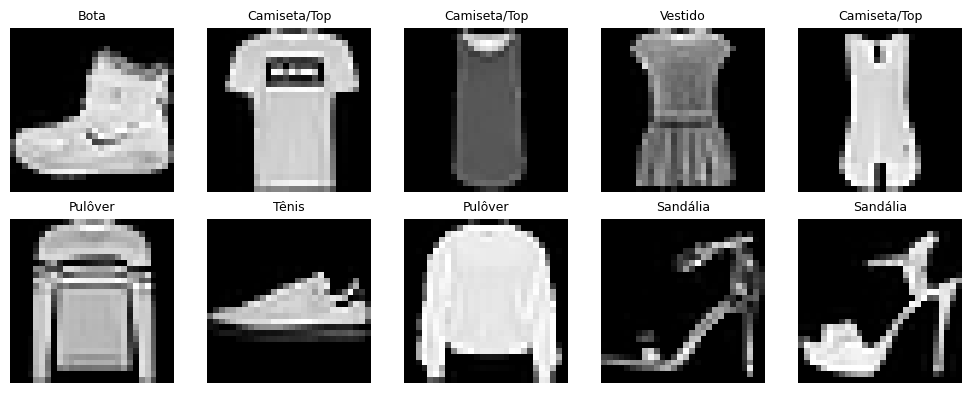

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(classes[y_train[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Pré-processamento

Normalizamos os pixels para o intervalo `[0, 1]` e adicionamos a dimensão de canal → `(N, 28, 28, 1)`.

In [4]:
x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test  = (x_test.astype("float32")  / 255.0)[..., None]

print("Shape treino:", x_train.shape)
print("Shape teste: ", x_test.shape)

Shape treino: (60000, 28, 28, 1)
Shape teste:  (10000, 28, 28, 1)


## 4. Função de perda NLL (equivalente ao `nn.NLLLoss()`)

No PyTorch, `nn.NLLLoss()` recebe **log-probabilidades** (saída do `log_softmax`) e retorna `-log_prob[classe_correta]`. Reproduzimos exatamente esse comportamento aqui.

In [5]:
def nll_loss(y_true, y_pred):
    # y_pred: log-probabilidades (saída do log_softmax)
    # y_true: rótulos inteiros (0..9)
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    onehot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
    return -tf.reduce_mean(tf.reduce_sum(onehot * y_pred, axis=-1))

## 5. Arquitetura da CNN

Observações da tradução PyTorch → Keras:
- **Padding padrão** do PyTorch (`0`) = `padding="valid"` no Keras (default) → dimensões caem 24→12→8→4.
- **Dropout padrão** do PyTorch = `0.5`.
- **`log_softmax`** aplicado como ativação da última camada via `tf.nn.log_softmax`.

In [9]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(10, kernel_size=5),          # 10 canais, kernel 5x5, padding padrão (valid)
    layers.MaxPooling2D(pool_size=2),          # max pooling 2x2
    layers.ReLU(),

    layers.Conv2D(20, kernel_size=5),          # 20 canais, kernel 5x5, padding/passo padrão
    layers.Dropout(0.5),                        # dropout probabilidade padrão (0.5)
    layers.MaxPooling2D(pool_size=2),          # max pooling 2x2
    layers.ReLU(),

    layers.Flatten(),
    layers.Dense(50),                           # transformação afim -> 50
    layers.ReLU(),
    layers.Dense(10, activation=tf.nn.log_softmax),  # afim -> 10 + log_softmax
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 20)       │         5,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        16,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,840 (85.31 KB)

 Trainable params: 21,840 (85.31 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compilar — Adam (lr=0.001) + NLLLoss

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=nll_loss,
    metrics=["accuracy"],
)

## 7. Treinar o modelo

In [8]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=64,
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7722 - loss: 0.6186 - val_accuracy: 0.8387 - val_loss: 0.5410
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8443 - loss: 0.4292 - val_accuracy: 0.8710 - val_loss: 0.4393
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8617 - loss: 0.3818 - val_accuracy: 0.8726 - val_loss: 0.4037
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8726 - loss: 0.3524 - val_accuracy: 0.8717 - val_loss: 0.3952
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8799 - loss: 0.3336 - val_accuracy: 0.8830 - val_loss: 0.3575
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8847 - loss: 0.3188 - val_accuracy: 0.8845 - val_loss: 0.3530
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8887 - loss: 0.3082 - val_accuracy: 0.8853 - val_loss: 0.3445
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8901 - loss: 0.3000 - val_accuracy: 0

## 8. Avaliar no conjunto de teste

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Acurácia no teste: {test_acc:.4f}")
print(f"Loss no teste:     {test_loss:.4f}")

Acurácia no teste: 0.1145
Loss no teste:     2.2946


## 9. Curvas de treino

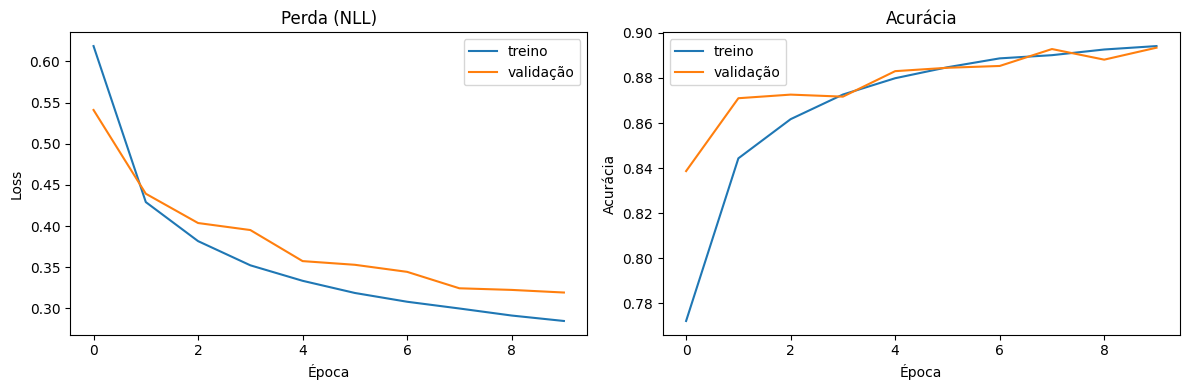

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="treino")
ax1.plot(history.history["val_loss"], label="validação")
ax1.set_title("Perda (NLL)"); ax1.set_xlabel("Época"); ax1.set_ylabel("Loss"); ax1.legend()

ax2.plot(history.history["accuracy"], label="treino")
ax2.plot(history.history["val_accuracy"], label="validação")
ax2.set_title("Acurácia"); ax2.set_xlabel("Época"); ax2.set_ylabel("Acurácia"); ax2.legend()

plt.tight_layout()
plt.show()

## 10. Exemplos de previsões

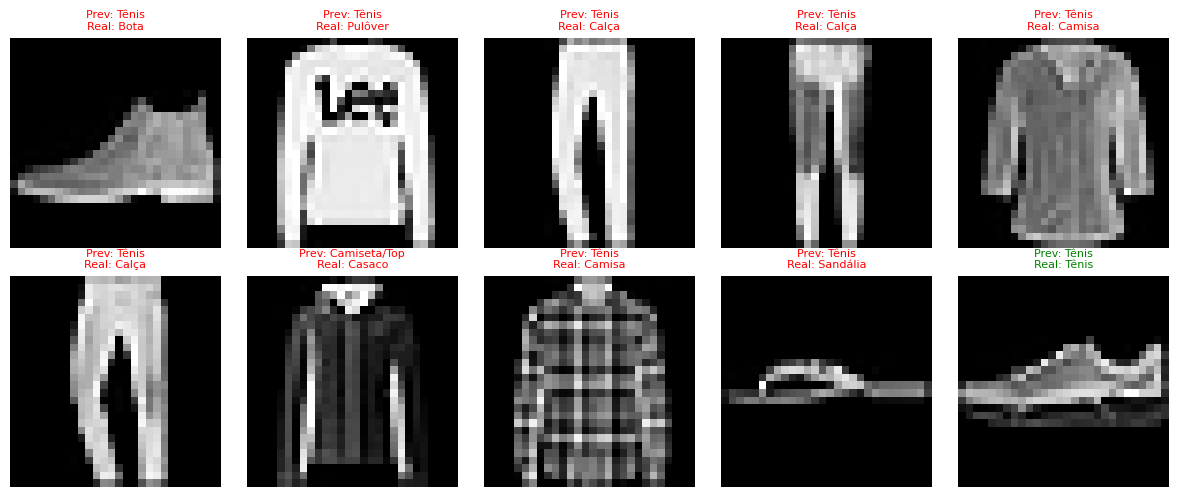

In [13]:
# log_softmax -> exp() converte de volta para probabilidades
log_probs = model.predict(x_test[:10], verbose=0)
preds = np.argmax(log_probs, axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    cor = "green" if preds[i] == y_test[i] else "red"
    plt.title(f"Prev: {classes[preds[i]]}\nReal: {classes[y_test[i]]}", fontsize=8, color=cor)
    plt.axis("off")
plt.tight_layout()
plt.show()